---
# Project - Credit Card Fraud Detection
---

## Import Libraries
---

In [1]:
import pandas as pd
# In our dataset, there are more columns so we need to change the default settings of pandas library
pd.set_option('display.max_columns', 100)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV
kfold = StratifiedKFold(n_splits=5)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import  classification_report, confusion_matrix, roc_auc_score, roc_curve



import warnings
warnings.filterwarnings('ignore')

## Load the Dataset
---

In [2]:
# Load dataset and store it into df_raw
df_raw = pd.read_csv(r'D:\Shubham\Python ML\Credit Card Fraud Detection\creditcard.csv')
df_raw.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Checking for Null Values, Dtype and Shape of the dataset
---

In [3]:
# Check Null Values
df_raw.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [4]:
# Shape of the dataset

print(f'Number of rows: {df_raw.shape[0]}')
print(f'Number of columns: {df_raw.shape[1]}')

Number of rows: 284807
Number of columns: 31


In [5]:
# Check Data type
df_raw.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

### Insights:
- No missing values are present in the dataset.
- Data types: All features are of type float64, except the target variable `Class`, which is of type int.
- Dataset shape:
- `Rows` (transactions): 284,807
- `Columns` (features): 31

# Class Distribution
---

Class Distribution (count):
Class
0    28431500
1       49200
Name: count, dtype: int64

Class Distribution (percent):
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


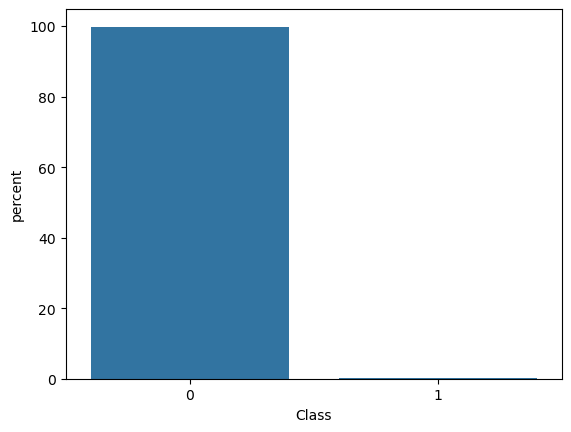

In [6]:
# Class 0 for non-fraud and class 1 for fraud
sns.countplot(x=df_raw['Class'], stat='percent')
print(f'Class Distribution (count):\n{df_raw['Class'].value_counts()*100}\n')
print(f'Class Distribution (percent):\n{df_raw['Class'].value_counts(normalize=True)*100}')


## Insights:
- The target variable `Class` is highly imbalanced.
- Out of `284,807` total transactions, only `492` are fraudulent (`≈0.17%`), while the remaining `284,315` are legitimate.
- This imbalance highlights the need for specialized techniques (e.g., resampling, SMOTE, or using precision/recall metrics) to ensure fraud cases are detected effectively.


## Scatter Plot for visualizing fraudulent transactions
---

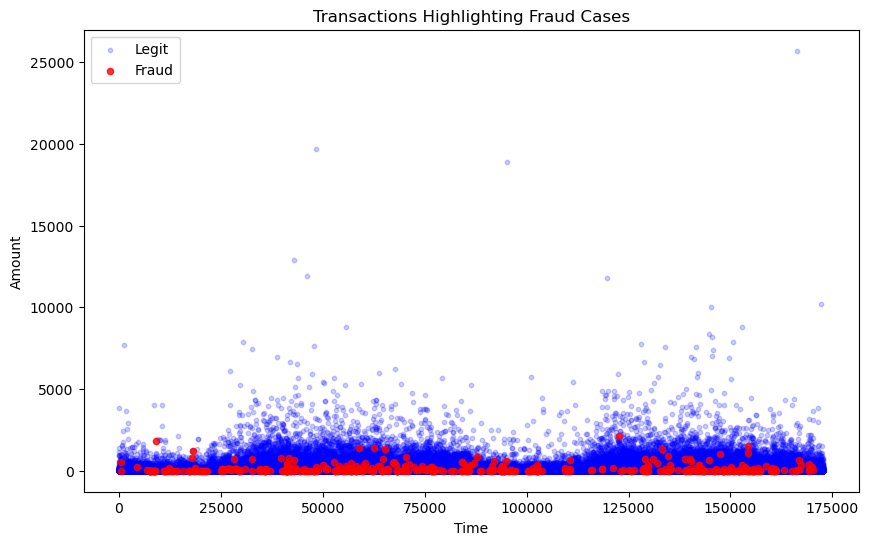

In [7]:
## Scatter Plot fraudulent transactions vs legit transactions
plt.figure(figsize=(10,6))
plt.scatter(df_raw[df_raw['Class']==0]['Time'], df_raw[df_raw['Class']==0]['Amount'],
            c='blue', alpha=0.2, s=10, label='Legit')
plt.scatter(df_raw[df_raw['Class']==1]['Time'], df_raw[df_raw['Class']==1]['Amount'],
            c='red', alpha=0.8, s=20, label='Fraud')
plt.title("Transactions Highlighting Fraud Cases")
plt.xlabel("Time")
plt.ylabel("Amount")
plt.legend()
plt.show()


### Insights:
- `Fraudulent transactions` in this dataset are generally `not high‑value payments`. They tend to occur at smaller or mid‑range amounts rather than at the extreme end of the scale.
- In contrast, `legit transactions` can span the full range, including `very large amounts`. This overlap means that simply flagging big payments as suspicious would be misleading. Many genuine purchases are large too.
- The takeaway is that transaction size alone isn’t a reliable signal of fraud; deeper patterns hidden in the PCA features are what truly help separate fraud from normal activity.

## Scale Amount and Time
---

In [8]:
## Scaling amount and time feature
scalar = StandardScaler()
df_raw[['Amount','Time']] = scalar.fit_transform(df_raw[['Amount','Time']])

## Split dataset into x and y variables
---

In [9]:
# x for other features and y for target feature
x = df_raw.drop(['Class'], axis=1)
y = df_raw[['Class']]

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=36, stratify=y)

In [22]:
train_df = pd.concat([x_train, y_train], axis=1)
test_df  = pd.concat([x_test, y_test], axis=1)

# Save to CSV
train_df.to_csv("train.csv.gz", index=False, compression="gzip")
test_df.to_csv("test.csv.gz", index=False, compression="gzip")



In [11]:
# Shape of x_train, x_test, y_train, y_test
print(f'Shape of X train: {x_train.shape}')
print(f'Shape of X test: {x_test.shape}')
print(f'Shape of Y train: {y_train.shape}')
print(f'Shape of Y test: {y_test.shape}')

Shape of X train: (227845, 30)
Shape of X test: (56962, 30)
Shape of Y train: (227845, 1)
Shape of Y test: (56962, 1)


## Treat Class Imbalance
---

In [12]:
%%capture
# Class balance for train dataset.
smote = SMOTE(random_state=42)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

In [13]:
# Shape of new balanced dataset
print(f'Shape of X train Resample: {x_train_resampled.shape}')
print(f'Shape of Y train Resample: {y_train_resampled.shape}')

Shape of X train Resample: (454902, 30)
Shape of Y train Resample: (454902, 1)


# Model Training

---

## Logistic Regression
---

In [14]:
lr = LogisticRegression()

# Make a grid of parameters
grid_lr = {"penalty" : ['l1', 'l2', 'elasticnet'],
    "class_weight": ['balanced'],
    "random_state": [36,42,66],
    "solver": ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'],
    "max_iter": [100],
    "multi_class": ['auto', 'ovr', 'multinomial'],
    "n_jobs": [-1]}

# now fit these parameters
model_grid_lr = RandomizedSearchCV(estimator=lr,
                                   param_distributions=grid_lr,
                                   n_iter=6,
                                   cv=kfold)
model_grid_lr.fit(x_train_resampled, y_train_resampled)

# Choose best estimator 
best_model_lr = model_grid_lr.best_estimator_

In [15]:
def evaluate_model(y_true, y_pred, model, model_name):
    print(f'{model_name} Results:\n')
    print(f'Accuracy Score: {accuracy_score(y_true, y_pred)}')
    print(f'Precision Score: {precision_score(y_true, y_pred)}')
    print(f'Recall Score: {recall_score(y_true, y_pred)}')
    print(f'F1 Score: {f1_score(y_true, y_pred)}')
    print(f'\nClassification Report:\n {classification_report(y_true, y_pred)}')
    y_pred_prob = model.predict_proba(x_test)[:,1]
    roc_auc = roc_auc_score(y_true, y_pred_prob)
    print(f'{model_name}: {roc_auc}')
    plt.figure(figsize=(6,5))
    # Confusion Matrix
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.3f})")
    plt.plot([0,1],[0,1],'k--')
    plt.title(f"{model_name} ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

Logistic Regression Results:

Accuracy Score: 0.975632878059057
Precision Score: 0.06182065217391304
Recall Score: 0.9285714285714286
F1 Score: 0.1159235668789809

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.93      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

Logistic Regression: 0.977997807873853


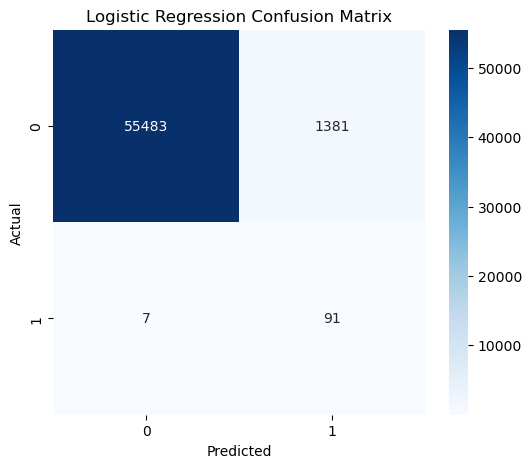

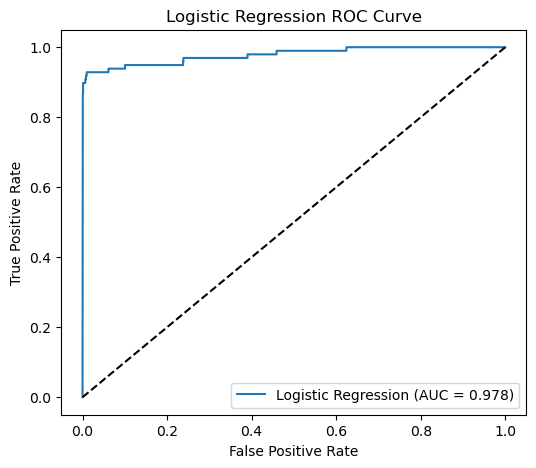

In [16]:
y_pred_lr = best_model_lr.predict(x_test)
evaluate_model(y_test, y_pred_lr, best_model_lr, 'Logistic Regression')

In [17]:
import joblib
joblib.dump(best_model_lr, 'best_model.pkl')

['best_model.pkl']